In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import os

# Section 1: Open and Inspect

In [2]:
ersst_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc"
ds = xr.open_dataset(
    ersst_url,
    drop_variables=["time_bnds"]
)

In [3]:
ds.sst

<xarray.DataArray 'sst' (time: 2061, lat: 89, lon: 180)> Size: 132MB
[33017220 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 16kB 1854-01-01 1854-02-01 ... 2025-09-01
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

In [4]:
print("Dimensions: ", ds.dims)
print("Coodrinates: ", ds.coords)
print("Attributed: ", ds.attrs)

Dimensions:  FrozenMappingWarningOnValuesAccess({'lat': 89, 'lon': 180, 'time': 2061})
Coodrinates:  Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 16kB 1854-01-01 1854-02-01 ... 2025-09-01
Attributed:  {'climatology': 'Climatology is based on 1971-2000 SST, Xue, Y., T. M. Smith, and R. W. Reynolds, 2003: Interdecadal changes of 30-yr SST normals during 1871.2000. Journal of Climate, 16, 1601-1612.', 'description': 'In situ data: ICOADS2.5 before 2007 and NCEP in situ data from 2008 to present. Ice data: HadISST ice before 2010 and NCEP ice after 2010.', 'keywords_vocabulary': 'NASA Global Change Master Directory (GCMD) Science Keywords', 'keywords': 'Earth Science > Oceans > Ocean Temperature > Sea Surface Temperature >', 'instrument': 'Conventional thermometers', 'source_comment': 'SSTs were observed by conventional thermomet

The dimensions component of the xarray data model (dims) display the dimension names of each axis defined for a data array. On the other hand, the coordinates (coords) are the exact points of a dimension that enable label-based indexing of a data array. Finally, attributes (attrs) provide key metadata information about the entire dataset and data variables. These different components of the xarray data model are the structural components which each uniquely enable effective, management, manipulation and preservation of multidimentional environmental data. 

# Section 2: Space-time subsetting and units

In [5]:
### Time Subset 1

ds_sub = ds.sel(
    time=slice(
        "1982-01",
        "2024-12"
    )
)

### El Niño Region Subset
el_nino_bounds = ds_sub.sel(lat=slice(5, -5), 
                       lon=slice(120, 170))

In [6]:
print("dataset: ", ds.sst.dataset, "\n\n",
      "SST units: ", ds.sst.units, "\n\n",
      "Long name: ", ds.sst.long_name, "\n\n",
      "Statistic: ", ds.sst.statistic, "\n\n",
      "Long_name: ", ds.sst.var_desc, "\n\n",
      "actual range: ", ds.sst.actual_range, "\n\n",
      "valid_range: ", ds.sst.valid_range)

dataset:  NOAA Extended Reconstructed SST V5 

 SST units:  degC 

 Long name:  Monthly Means of Sea Surface Temperature 

 Statistic:  Mean 

 Long_name:  Sea Surface Temperature 

 actual range:  [-1.8     42.32636] 

 valid_range:  [-1.8 45. ]


# Section 3: Climatology, Monthly Means, & Anomolies

In [7]:
# Compute monthly climatology over 1982-2011
ds_sub2 = el_nino_bounds.sel(
    time=slice(
    "1982-01", 
    "2011-12"
    )
)
regional_monthly_climatology = ds_sub2.sst.groupby("time.month").mean("time")

# Compute SST anomalies 
regional_sst_anomalies = el_nino_bounds.groupby('time.month') - regional_monthly_climatology

In [8]:
# Compute lat weights
weights = np.cos(np.deg2rad(el_nino_bounds.lat))

# Compute mean SST anomalies
weighted_monthly_mean_sst = el_nino_bounds.sst.weighted(weights).mean(dim=("lat", "lon"))

# Compute weighted SST anomalies
weighted_monthly_sst_anomalies = regional_sst_anomalies.weighted(weights).mean(dim=("lat", "lon"))

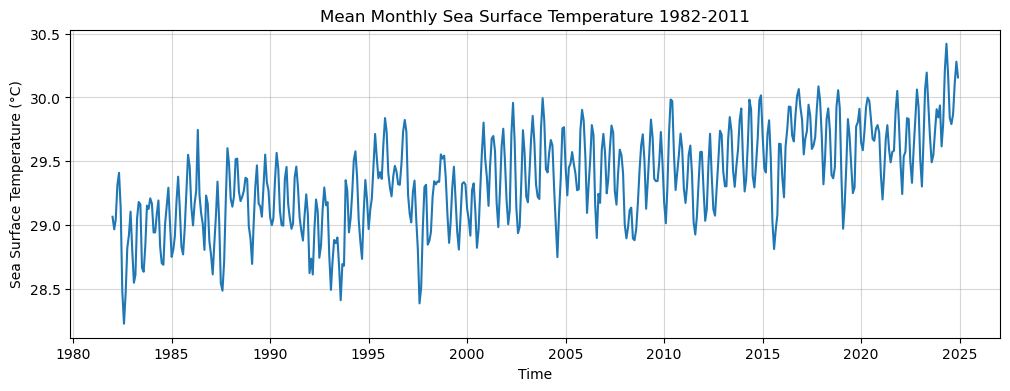

In [9]:
plt.figure(figsize=(12, 4))
weighted_monthly_mean_sst.plot()
plt.title("Mean Monthly Sea Surface Temperature 1982-2011")
plt.xlabel("Time")
plt.ylabel("Sea Surface Temperature (°C)")
plt.grid(True, alpha=0.5)
plt.show()

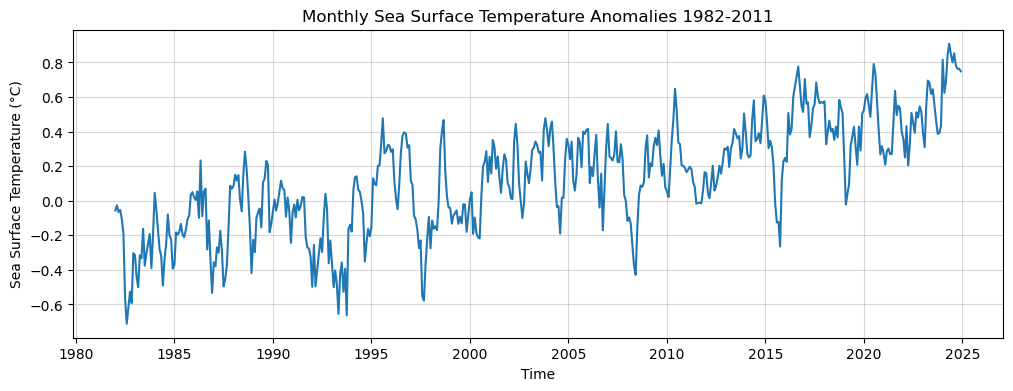

In [10]:
plt.figure(figsize=(12, 4))
weighted_monthly_sst_anomalies.sst.plot()
plt.title("Monthly Sea Surface Temperature Anomalies 1982-2011")
plt.xlabel("Time")
plt.ylabel("Sea Surface Temperature (°C)")
plt.grid(True, alpha=0.5)
plt.show()
plt.show()

# Section 4: Rolling Index and Event Detection

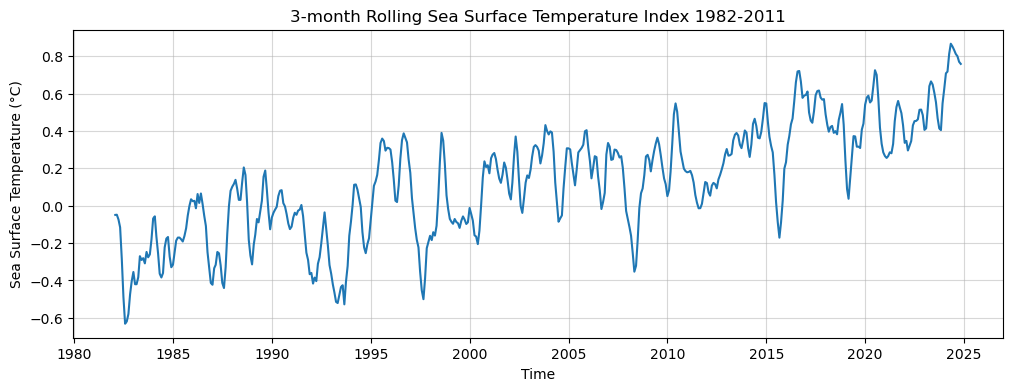

In [11]:
ds_anom_rolling = weighted_monthly_sst_anomalies.rolling(time=3, center=True).mean()

plt.figure(figsize=(12, 4))
ds_anom_rolling.sst.plot()
plt.title("3-month Rolling Sea Surface Temperature Index 1982-2011")
plt.xlabel("Time")
plt.ylabel("Sea Surface Temperature (°C)")
plt.grid(True, alpha=0.5)
plt.show()
plt.show()

In [12]:
warm_mask = weighted_monthly_sst_anomalies >= 0.5
cold_mask = weighted_monthly_sst_anomalies <= -0.5

sst_warm = warm_mask.rolling(time=3).sum() >= 3
sst_cold = cold_mask.rolling(time=3).sum() >= 3

print(sst_warm.sst.sum().values)
print(sst_cold.sst.sum().values)

34
3


In [ ]:
select_top3 = weighted_monthly_sst_anomalies.sst.where(sst_warm.sst, drop=True)

### Generated using ChatGPT
sorted_masked = select_top3.sortby(select_top3, ascending=False)

top3 = sorted_masked.isel(time=slice(0, 3))

### Generated using ChatGPT
for val, date in zip(top3.values, top3['time'].values):
    print(f"Date: {date}, Value: {val}")

weighted_monthly_sst_anomalies.where(sst_warm.sst, drop=True)


Date: 2024-05-01T00:00:00.000000000, Value: 0.9081089496612549
Date: 2024-08-01T00:00:00.000000000, Value: 0.8526482582092285
Date: 2024-06-01T00:00:00.000000000, Value: 0.8472207188606262


<xarray.Dataset> Size: 680B
Dimensions:  (time: 34)
Coordinates:
  * time     (time) datetime64[ns] 272B 2016-08-01 2016-09-01 ... 2024-12-01
    month    (time) int64 272B 8 9 10 11 12 1 2 3 8 9 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time) float32 136B 0.7175 0.7765 0.6684 ... 0.7633 0.7638 0.7485

In [66]:
select_top3 = weighted_monthly_sst_anomalies.sst.where(sst_cold.sst, drop=True)

### Generated using ChatGPT
sorted_masked = select_top3.sortby(select_top3, ascending=True)

top3 = sorted_masked.isel(time=slice(0, 3))

### Generated using ChatGPT
for val, date in zip(top3.values, top3['time'].values):
    print(f"Date: {date}, Value: {val}")

weighted_monthly_sst_anomalies.where(sst_cold.sst, drop=True)

Date: 1982-09-01T00:00:00.000000000, Value: -0.6198871731758118
Date: 1982-11-01T00:00:00.000000000, Value: -0.5922843813896179
Date: 1982-10-01T00:00:00.000000000, Value: -0.5257688164710999


<xarray.Dataset> Size: 60B
Dimensions:  (time: 3)
Coordinates:
  * time     (time) datetime64[ns] 24B 1982-09-01 1982-10-01 1982-11-01
    month    (time) int64 24B 9 10 11
Data variables:
    sst      (time) float32 12B -0.6199 -0.5258 -0.5923

In [15]:
print(os.getcwd())
dataset = xr.Dataset({'time': weighted_monthly_sst_anomalies.time, 
                      'anomaly': weighted_monthly_sst_anomalies.sst, 
                      'rolling_anomaly': ds_anom_rolling.sst}) 
dataframe = dataset.to_dataframe()
dataframe.to_csv('/Users/lberg/geog313-assignments/assignment-3/results/region_index.csv', index=False)

/Users/lberg/geog313-assignments/assignment-3/notebooks


The top three warm El Niño events occurred in the year 2024 in May, June and August 2024. The peak magniude was 0.91°C which lasted from May to Ugust (4 months).

The top three cold La Niña events occurred in the year 1982 in September, October and November 1982. The peak magniude was -0.61 which lasted from September to November 1982. 

# Section 5

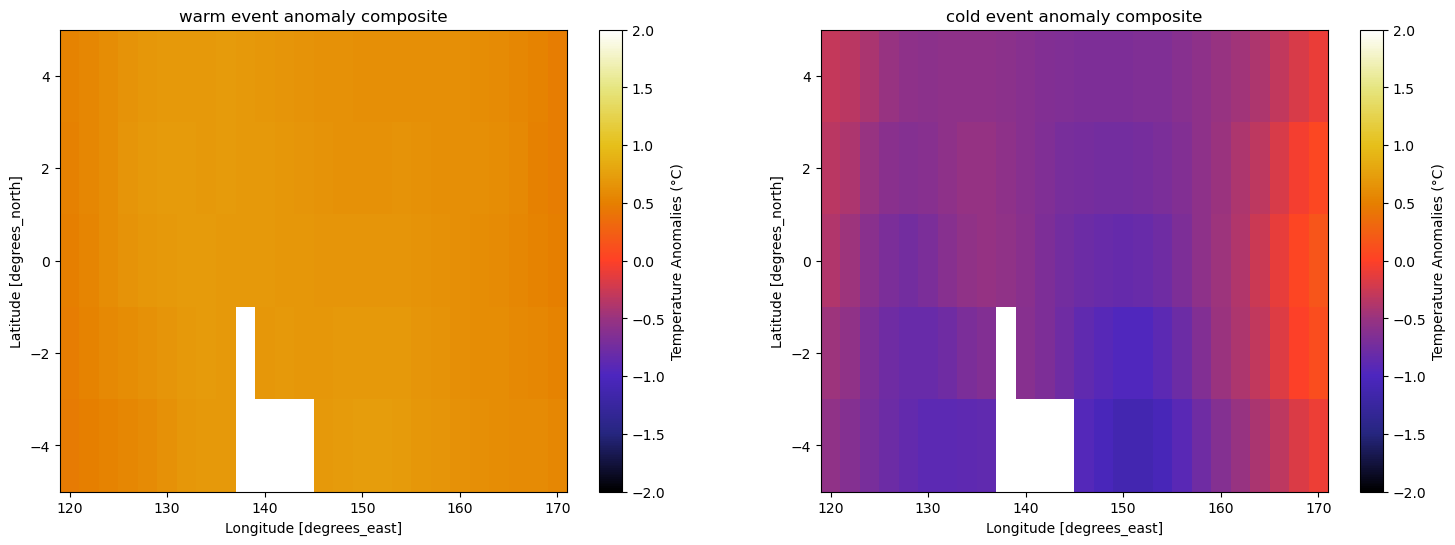

In [ ]:
# .where sectin of code obtained from ChatGPT output
sst_warm_composite = regional_sst_anomalies.where(warm_mask).mean(dim='time')
sst_cold_composite = regional_sst_anomalies.where(cold_mask).mean(dim='time')


# axes[0], axes[2] portion obtained from ChatGPT output
fig, axes = plt.subplots(1, 2, figsize =(18, 6))

sst_warm_composite.sst.plot(ax=axes[0], cmap='CMRmap', vmin=-2, vmax=2, 
                        cbar_kwargs={'label':'Temperature Anomalies (°C)'})
axes[0].set_title("warm event anomaly composite")

sst_cold_composite.sst.plot(ax=axes[1], cmap='CMRmap', vmin=-2, vmax=2,
                        cbar_kwargs={'label':'Temperature Anomalies (°C)'})
axes[1].set_title("cold event anomaly composite")
plt.show()
sst_warm.to_netcdf('/Users/lberg/geog313-assignments/assignment-3/results/composite_warm.nc')
sst_cold.to_netcdf('/Users/lberg/geog313-assignments/assignment-3/results/composite_cold.nc')

In [17]:
sst_warm_composite.to_netcdf('/Users/lberg/geog313-assignments/assignment-3/results/composite_warm.nc')
sst_cold_composite.to_netcdf('/Users/lberg/geog313-assignments/assignment-3/results/composite_cold.nc')

There is a similar spatial pattern between the two warm and cold event anomaly composites. In the warm anomaly composite, warm temperatures are found within the middel to left (midwest to west) areas while colder temperatures are located on the right (east) side of the composite. In the cold color composite, the results are almost the opposite; here, cold temperatures are located within the middle to left (midwest to west) areas where warm temperatures were in the warm composite, whereas warm temperatures are located in the on the right (east) where cold temperatures were located in the warm composite.

# Section 6: Grid Comparison - Coarsen vs. Interpolate

In [18]:
coarsened_anomalies = regional_sst_anomalies.coarsen(lat=2, lon=2, boundary="trim").mean()
coarsened_anomalies

new_lats = np.arange(-90, 91, 4)
new_lons = np.arange(0, 361, 4)

interpolated_anomalies = regional_sst_anomalies.interp(lat=el_nino_bounds.lat, lon=el_nino_bounds.lon, method='linear')
interpolated_anomalies

<xarray.Dataset> Size: 277kB
Dimensions:  (time: 516, lat: 5, lon: 26)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1982-01-01 1982-02-01 ... 2024-12-01
    month    (time) int64 4kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float32 20B 4.0 2.0 0.0 -2.0 -4.0
  * lon      (lon) float32 104B 120.0 122.0 124.0 126.0 ... 166.0 168.0 170.0
Data variables:
    sst      (time, lat, lon) float32 268kB -0.08245 -0.1102 ... 0.4929 0.4662

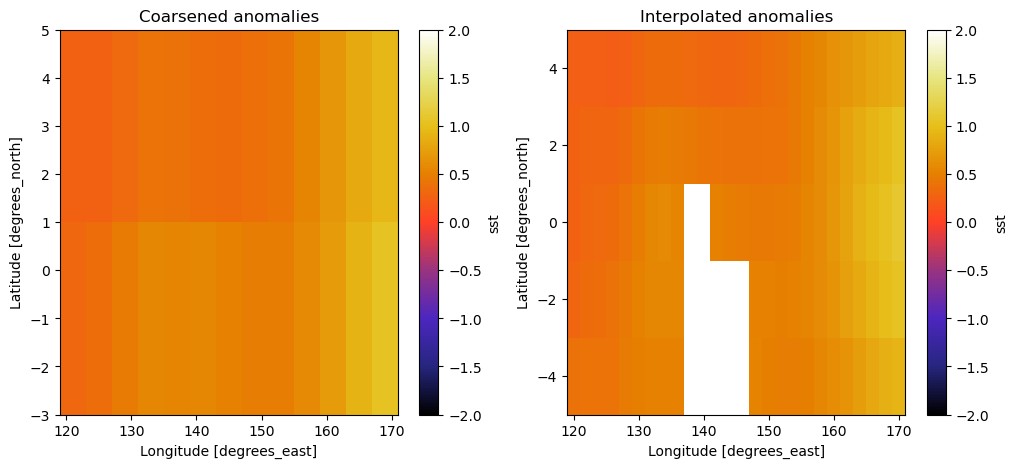

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
coarsened_anomalies.sst.sel(time="2020-01-01", method='nearest').plot(ax=axes[0], 
                                                    vmin=-2, vmax=2, cmap='CMRmap')
axes[0].set_title("Coarsened anomalies")

interpolated_anomalies.sst.sel(time="2020-01-01", method='nearest').plot(ax=axes[1], 
                                                       vmin=-2, vmax=2, cmap='CMRmap')
axes[1].set_title("Interpolated anomalies")
plt.show()

### **Coarsen**
**Pros**: 
- Works well with large datasets because it reduces its total number of data points for one or more axes.
- Straight forward in terms of enabling aggregation over blocks through different methods (mean, sum).
- Computationally faster and resuces noise from high resolution data.

**Cons**:
- Important data could be lost and resolution might not be able to capture important data that otherwise
  Could be found at finer scales.
- Doesn't work well with non-uniform data grids and some further data processing might need to be performed.

### **Interpolate**
**Pros**:
- Increases resolution by enabling values to be created at finer scales.
- Provides accurate resampling to any new coordinates and allows for multiple methods (linear, nearest, cubic).
- Fills in gaps of missing data and can be used for both increasing and decreasing data resolution.

**Cons**: 
- Computationally exhaustive/expensive especially with large datasets
- Could potentially lead to data overfitting and/or introduce bias that may be misleading

# Optional: Trend Analysis

Error:DAP DATADDS packet is apparently too short


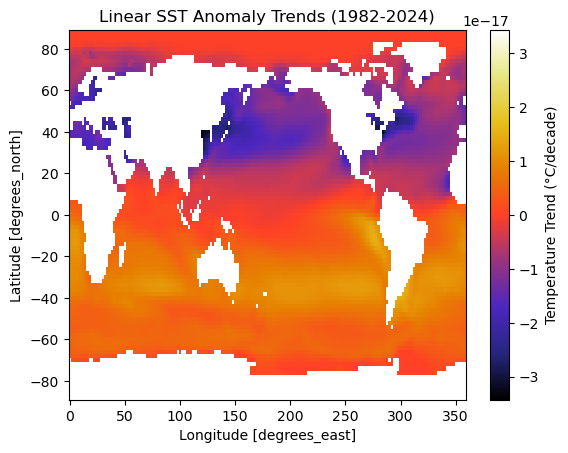

In [20]:
gb = ds_sub.groupby('time.month')
ds_anom = gb - gb.mean(dim='time')

monthly_sst_anomalies_trend = ds_anom.sst.polyfit(dim='time', deg=1)

# Generated lower 2 lines of code using ChatGPT
slope_map = monthly_sst_anomalies_trend['polyfit_coefficients'].sel(degree=1)
slope_per_decade = slope_map * 120 
slope_per_decade.plot(cmap='CMRmap', center=0, cbar_kwargs={'label': 'Temperature Trend (°C/decade)'})
plt.title('Linear SST Anomaly Trends (1982-2024)')
plt.show()

According to the trend map, the majority of regions south of the equador are experiencing positive warming trends compared regions between 0 and 70° N which are experiencing negative warming trends. Regions of the Pacific Ocean between Africa and Australia are experiencing the most warming trends (regions in the Atlantic and Indian Ocean are also experiencing notably high trends) out of the rest of the regions, whereas the upper Pacific and Atlantic Ocean is experiencing the highest negative warming trend per decade. Furthermore, regions around the Arctic above Russia, Canada and Greenland are predominantly experiencing zero or slight negative warming trends. 

Linear trends are not very representative of real world ocean temperature trends (or other multidimensional trends) as they tend to generalize temporal oscillations of temperature change. These regions typically exhibit a wide range of seasonal and annual changes resulting in high temporal variability in these areas. Therefore, since this period covers about 42 years, much of the short and medium-term (ENSO, PDO) variability may be captured.